# Q1: Setup & Exploration

**Phase 1-2:** Project Setup, Data Exploration  
**Points: 6 points**

**Focus:** Load data, perform initial inspection, identify data quality issues.

**Lecture Reference:** Lecture 11, Notebook 1 ([`11/demo/01_setup_exploration_cleaning.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/01_setup_exploration_cleaning.ipynb)), Phases 1-2. Also see Lecture 04 (pandas I/O) and Lecture 07 (visualization).

---

## Setup

In [32]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os

# Create output directory
os.makedirs('output', exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
# 1. `output/q1_data_info.txt`

# Load Data 
df = pd.read_csv('data/beach_sensors.csv')

# to datetime Measurement Timestamp, Measurement Time Stamp Label

# Dataset shape (rows × columns)
df_shape = df.shape

# Column names (one per line or comma-separated)
df_colnames = df.columns.tolist()

# Data types for each column | Convert datetime
df_types_old = df.dtypes 
print(df_types_old)
print(df.head(2))
df['Measurement Timestamp'] = pd.to_datetime(df['Measurement Timestamp'])
df['Measurement Timestamp Label'] = pd.to_datetime(df['Measurement Timestamp Label'])
df_types = df.dtypes

# Date range (start date and end date) - **REQUIRED if temporal data**
df_date_range = {'Start Date': df['Measurement Timestamp Label'].min(), 'End Date': df['Measurement Timestamp Label'].max()}

# Missing value counts for each column 
df_missing_col = df.isnull().sum()

# Count Per Site
print(df.groupby('Station Name').size())

# Output q1_data_info.txt
with open('output/q1_data_info.txt', 'w') as f:
    f.write(f'Dataset Shape: {df_shape[0]} rows x {df_shape[1]} columns\n\n')
    f.write('Column Names:\n')
    for col in df_colnames:
        f.write(f'- {col}\n')
    f.write('\nData Types:\n')
    for col, dtype in df_types.items():
        f.write(f'- {col}: {dtype}\n')
    f.write('\nDate Range:\n')
    f.write(f'Start: {df_date_range['Start Date']}\n')
    f.write(f'End: {df_date_range['End Date']}\n')
    f.write('\nMissing Values:\n')
    for col, missing in df_missing_col.items():
        percentage = missing / df_shape[0] * 100
        f.write(f'- {col}: {missing} ({percentage:.1f}%)\n')


Station Name                    object
Measurement Timestamp           object
Air Temperature                float64
Wet Bulb Temperature           float64
Humidity                         int64
Rain Intensity                 float64
Interval Rain                  float64
Total Rain                     float64
Precipitation Type             float64
Wind Direction                   int64
Wind Speed                     float64
Maximum Wind Speed             float64
Barometric Pressure            float64
Solar Radiation                  int64
Heading                        float64
Battery Life                   float64
Measurement Timestamp Label     object
Measurement ID                  object
dtype: object
                  Station Name   Measurement Timestamp  Air Temperature  \
0  63rd Street Weather Station  09/27/2018 10:00:00 AM             16.4   
1  63rd Street Weather Station  09/27/2018 11:00:00 AM             17.1   

   Wet Bulb Temperature  Humidity  Rain Intensity  Interva

In [34]:
# 2. `output/q1_exploration.csv`

# Extract Numeric Columns
df_numeric = df.select_dtypes(include = 'number')

# Calculate Exploration Data
exploration = {
    'column_name' : df_numeric.columns,
    'mean' : df_numeric.mean(),
    'std' : df_numeric.std(),
    'min' : df_numeric.min(),
    'max' : df_numeric.max(),
    'missing_count' : df_numeric.isnull().sum()
}

# Convert Dictionary to Dataframe
exploration_df = pd.DataFrame(exploration)

# Output q1_exploration.csv
exploration_df.to_csv('output/q1_exploration.csv', index = False)

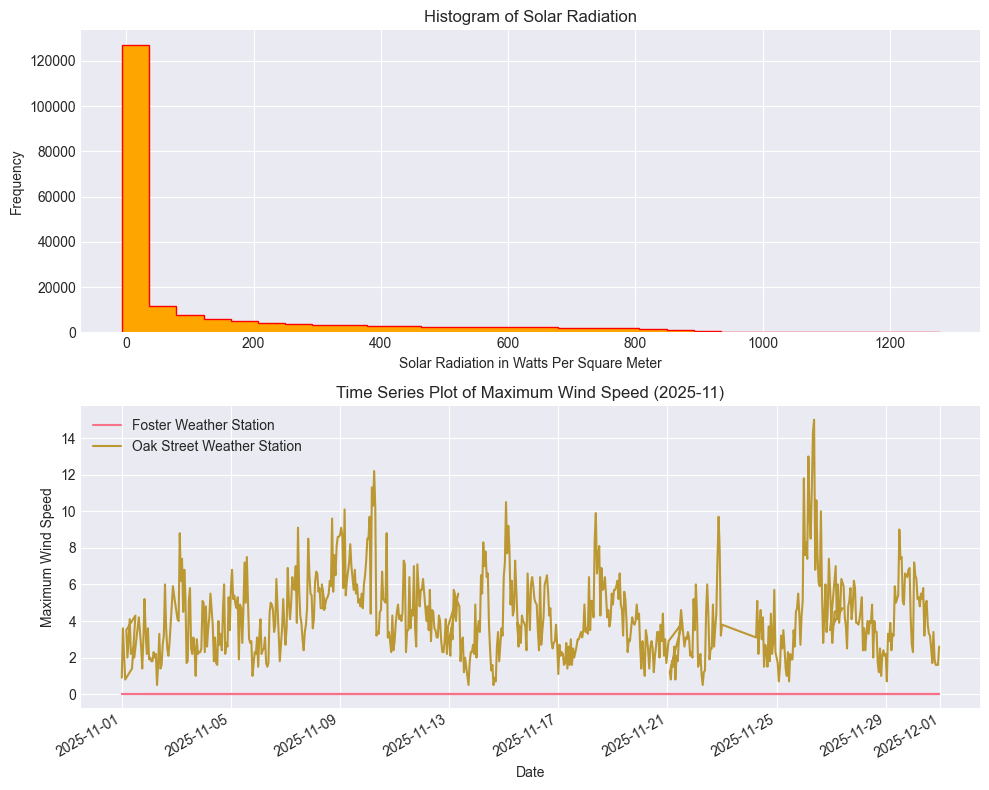

In [35]:
# 3. `output/q1_visualizations.png`

# Set up Subplots
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize = (10, 8))

# Histogram Solar Radiation => -100,000 and 0 Missing Data
## Unrestricted Histogram too Zoomed Out => 
## Set -10000 as Minimum to Test -100,000 was filled in value
df_min_solar = df[df['Solar Radiation'] >= -10000]
df_min_solar['Solar Radiation'].plot(
    kind = 'hist',
    ax = axes[0],
    color = 'Orange',
    bins = 30
)

## Red Outline
df_min_solar['Solar Radiation'].plot(
    kind = 'hist',
    ax = axes[0],
    histtype = 'step',
    color = 'Red',
    bins = 30,
    xlabel = 'Solar Radiation in Watts Per Square Meter',
    ylabel = 'Frequency',
    title = 'Histogram of Solar Radiation'
)

# Time Series Interval Rain => Why -0.9 and When Data is Missing
## Restrict to Last Completed Month => Start: 2015-04-25 End: 2025-12-08 => 2025-11
df_2025_11 = df[
    (df['Measurement Timestamp'].dt.year == 2025) &
    (df['Measurement Timestamp'].dt.month == 11)
    ]

## Separate by Station to Identify Potentially Problematic Locations
for location in df_2025_11['Station Name'].unique():
    station = df_2025_11[df_2025_11['Station Name'] == location]
    station.plot(
        x = 'Measurement Timestamp',
        y = 'Maximum Wind Speed',
        ax = axes[1],
        label = location,
        xlabel = 'Date',
        ylabel = 'Maximum Wind Speed',
        title = 'Time Series Plot of Maximum Wind Speed (2025-11)'
    )

# Add Space to Prevent Scrunched Plots
plt.tight_layout()

# Output q1_visualizations.png
plt.savefig('output/q1_visualizations.png', dpi = 300, bbox_inches = 'tight')
plt.show()

---

## Objective

Load the Chicago Beach Weather Sensors dataset, perform initial inspection, and identify data quality issues.

**Note:** The datetime column in this dataset is named `Measurement Timestamp`.

**Time Series Note:** Unlike the lecture's NYC Taxi data (event-based), this dataset is **time-series data** with continuous sensor readings. The data is already indexed by time, so you'll work with datetime-indexed dataframes throughout. See **Lecture 09** for time series operations. For time series visualizations, you may want to use pandas `resample()` to aggregate data (e.g., daily averages) for clearer visualization of long-term trends.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q1_data_info.txt`
**Format:** Plain text file
**Content:** Dataset information including:
- Dataset shape (rows × columns)
- Column names (one per line or comma-separated)
- Data types for each column
- Date range (start date and end date) - **REQUIRED if temporal data**
- Missing value counts for each column (column name: count)

**Example format:**
```
Dataset Shape: 50000 rows × 10 columns

Column Names:
- Measurement Timestamp
- Beach
- Water Temperature
- Air Temperature
...

Data Types:
- Measurement Timestamp: datetime64[ns]
- Beach: object
- Water Temperature: float64
...

Date Range:
Start: 2022-01-01 00:00:00
End: 2027-09-15 07:00:00

Missing Values:
- Water Temperature: 2500 (5.0%)
- Air Temperature: 1500 (3.0%)
...
```

### 2. `output/q1_exploration.csv`
**Format:** CSV file
**Required Columns (exact names):** `column_name`, `mean`, `std`, `min`, `max`, `missing_count`
**Content:** One row per numeric column in the dataset
- `column_name`: Name of the numeric column
- `mean`: Mean value (float)
- `std`: Standard deviation (float)
- `min`: Minimum value (float)
- `max`: Maximum value (float)
- `missing_count`: Number of missing values (integer)

**Example:**
```csv
column_name,mean,std,min,max,missing_count
Water Temperature,15.23,5.12,0.5,28.7,2500
Air Temperature,18.45,8.23,-5.2,35.8,1500
Wind Speed,6.78,4.56,0.1,25.3,0
```

### 3. `output/q1_visualizations.png`
**Format:** PNG image file
**Content:** At least 2 plots in a single figure (use subplots)
**Required plots:**
1. **Distribution plot:** Histogram or density plot of at least one numeric variable
2. **Time series plot:** Line plot showing a numeric variable over time (if temporal data)

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

---

## Requirements Checklist

- [ ] Data loaded successfully from `data/beach_sensors.csv`
- [ ] Initial inspection completed (shape, info, head, describe)
- [ ] Missing values identified and counted
- [ ] Basic visualizations created (at least 2 plots: distribution + time series)
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Load and inspect the dataset** - Use standard pandas I/O and inspection methods
2. **Parse datetime** - Identify and convert datetime column(s)
3. **Identify missing values** - Count and calculate percentages per column
4. **Create visualizations** - Distribution plot + time series plot (use subplots)
5. **Save artifacts** - Write to the three required output files

---

## Decision Points

- **Visualization choices:** What types of plots best show your data? See Lecture 11 Notebook 1 for examples.
- **Data quality assessment:** What issues do you see? Missing data patterns? Outliers? Inconsistent formats? Document these for Q2.

---

## Checkpoint

After Q1, you should have:
- [ ] Data loaded successfully
- [ ] Basic statistics calculated
- [ ] Initial visualizations created (2+ plots)
- [ ] Data quality issues identified
- [ ] All 3 artifacts saved: `q1_data_info.txt`, `q1_exploration.csv`, `q1_visualizations.png`

---

**Next:** Continue to `q2_data_cleaning.md` for Data Cleaning.
